In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, solve_ivp
from scipy.interpolate import CubicSpline, interp1d

import sys
sys.path.append('../src/')
import importlib

#Required to save figures
import os

In [2]:
import Cosmology as cosmo
import Constants_Units as cu
import Theoretical_Setup as TS
import Cosmological_Reionization as CR

In [3]:
importlib.reload(cosmo)
importlib.reload(cu)
importlib.reload(TS)
importlib.reload(CR)

<module 'Cosmological_Reionization' from 'C:\\Users\\ysvad\\Research\\Galaxy_Formation\\Enhanced-Primordial-Spectrum\\Notebooks\\../src\\Cosmological_Reionization.py'>

# Standard Power Spectrum

In [4]:
# Evaluate and print the normalization factor
R8 = 8 / cosmo.h      # units of Mpc, evaluating sigma_8 at this radius

A = cosmo.sigma8_obs / TS.sigma_R(R8,0,np.inf) #Normalization to observed sigma_8 value
print(R8)
print(TS.sigma_R(R8,0,1000))
print(f"Normalization factor A for sigma_8 = {cosmo.sigma8_obs} is A = {A}")

11.940298507462686
0.00022313190425815244
Normalization factor A for sigma_8 = 0.811 is A = 3634.621425816868


In [5]:
"""

#Test 1: Testing the integrator and sigma value

def W_test(k,R):
    kR = k*R
    return kR

def P_test(k,z,cutoff=np.inf):
    if k<=cutoff:    
        return Pi_test(k)*T_test(k)**2
    else:
        return 0

# Primordial power spectrum (un-normalised)
def Pi_test(k):
    return k**cosmo.n

# Transfer Function
def T_test(k):
    return k

# Variance of smoothed density field (wrt radius, R)
def sigma_R_test(R,z=0,cutoff=1000):    
    # Integrand for the variance calculation
    def integral(k):
        return P_test(k,z,cutoff) * k**2 * W_test(k,R)**2 / (2 * np.pi**2)
    
    sigma2, _ = quad(integral, 0, np.inf, limit=500, epsabs=1e-5, epsrel=1e-5)
    return np.sqrt(sigma2)

test_val = sigma_R_test(8)

print(test_val)

integrator_tester = np.sqrt(64 / (2 * np.pi ** 2) * (1000) ** 7.965 / 7.965)

print(integrator_tester)

print(np.abs(test_val - integrator_tester) / integrator_tester * 100)

"""

'\n\n#Test 1: Testing the integrator and sigma value\n\ndef W_test(k,R):\n    kR = k*R\n    return kR\n\ndef P_test(k,z,cutoff=np.inf):\n    if k<=cutoff:    \n        return Pi_test(k)*T_test(k)**2\n    else:\n        return 0\n\n# Primordial power spectrum (un-normalised)\ndef Pi_test(k):\n    return k**cosmo.n\n\n# Transfer Function\ndef T_test(k):\n    return k\n\n# Variance of smoothed density field (wrt radius, R)\ndef sigma_R_test(R,z=0,cutoff=1000):    \n    # Integrand for the variance calculation\n    def integral(k):\n        return P_test(k,z,cutoff) * k**2 * W_test(k,R)**2 / (2 * np.pi**2)\n\n    sigma2, _ = quad(integral, 0, np.inf, limit=500, epsabs=1e-5, epsrel=1e-5)\n    return np.sqrt(sigma2)\n\ntest_val = sigma_R_test(8)\n\nprint(test_val)\n\nintegrator_tester = np.sqrt(64 / (2 * np.pi ** 2) * (1000) ** 7.965 / 7.965)\n\nprint(integrator_tester)\n\nprint(np.abs(test_val - integrator_tester) / integrator_tester * 100)\n\n'

In [6]:
k_range = np.linspace(1, 1000) #spatial modes from large scale (k=1) to small scale (k=1000)
P_old_test_vals = np.zeros((len(TS.z_range), len(k_range))) #Power spectrum array for various k vals at various z

for i in range(len(TS.z_range)):
    for j in range(len(k_range)):
        P_old_test_vals[i][j] = A ** 2 * TS.P(k_range[j], TS.z_range[i], cutoff = np.inf) #No upper cutoff in k placed, though it is cutoff by input

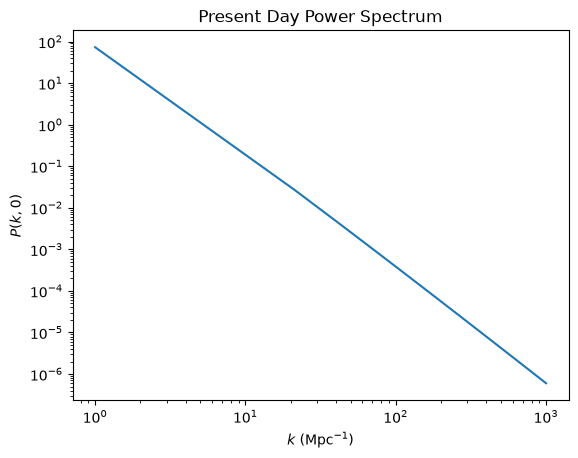

In [7]:
plt.loglog(k_range, P_old_test_vals[0], label = r'$A_\text{G}=0$')
plt.xlabel(r'$k$ (Mpc$^{-1}$)')
plt.ylabel(r'$P(k,0)$')
plt.title(r'Present Day Power Spectrum')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "Original_PresentDay_PS.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

# Enhanced Power Spectrum

In [8]:
def P_new(k, z, A_G, k_mean, k_std, cutoff=np.inf): #Defining new PS compatible with simpsons integration

    P = Pi_new(k, A_G, k_mean, k_std) * (TS.T(k) * TS.D(z))**2

    return np.where(k <= cutoff, P, 0.0) #Return P only for k vals below cutoff, all other P(k) set to 0.0


# Primordial matter power spectrum (un-normalised)
def Pi_new(k, A_G, k_mean, k_std):
    # Enhancement in form of localized gaussian at large k
    # Multiplying the gaussian with k_mean to make A_G dimensionless
    return (
        k ** cosmo.n
        * (
            1
            + k_mean
            * A_G
            * (1 / (k_std * np.sqrt(2 * np.pi)))
            * np.exp(-0.5 * ((k - k_mean) / k_std) ** 2)
        )
    )

In [9]:
#Gaussian Parameters

A_G_val = 6 * 10 ** 3 # Amplitude of the Gaussian
k_mean_val = np.array([30, 100, 270]) # Mean k around which the Gaussian is centered
k_std_val = 50 # Spread of the Gaussian

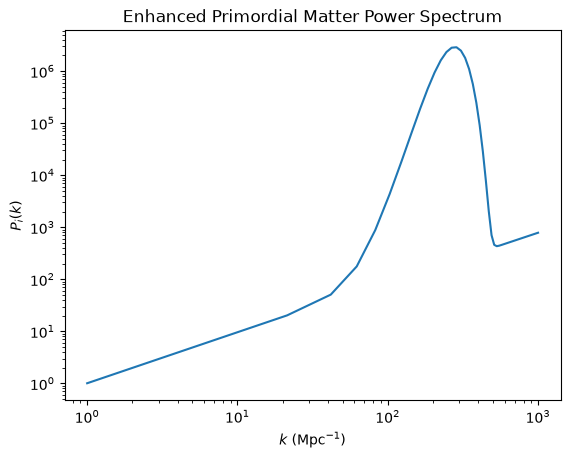

In [10]:
Pi_new_test_vals = Pi_new(k_range, A_G_val, k_mean_val[2], k_std_val)

plt.loglog(k_range, Pi_new_test_vals)
plt.xlabel(r'$k$ (Mpc$^{-1}$)')
plt.ylabel(r'$P_i(k)$')
plt.title(r'Enhanced Primordial Matter Power Spectrum')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "EnhancedPrimordial_PS.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [11]:
def sigma_R_new(R, A_G, k_mean, k_std, z=0, cutoff=np.inf): #defined for P_new2 to check simpson integrator
    # Defining k_grid such that we integrate over logk for better integration behaviour required by simpson
    logk = np.linspace(-4, 5, 20000)
    k = 10**logk

    integrand = (
        np.log(10)
        * P_new(k, z, A_G, k_mean, k_std, cutoff)
        * k**3
        * TS.W(k, R)**2
        / (2*np.pi**2)
    )

    sigma2 = simpson(integrand, x=logk)

    return np.sqrt(sigma2)

# Variance of smoothed density field (wrt mass of region, M)
def sigma_M_new(M, A_G, k_mean, k_std, z=0, cutoff=np.inf):
    # Compute R corresponding to the mass M
    R = (3 * M / (4 * np.pi * cosmo.rho_0))**(1/3)
    
    return sigma_R_new(R,A_G, k_mean, k_std, z, cutoff)

In [12]:
M_range_new = np.logspace(2, 11, 1000)

In [13]:
# Evaluate and print the normalization factor for enhanced PS

A_new = cosmo.sigma8_obs/sigma_R_new(R8, A_G_val, k_mean_val[2], k_std_val, 0)

#We expect similar normalization to original PS because only gaussian bump changes, and it does not contripute much to R=8/h

print(sigma_R_new(R8, A_G_val, k_mean_val[2], k_std_val))
print(f"Normalization factor A for sigma_8 = {cosmo.sigma8_obs} is A = {A_new}")

0.00022381150024233264
Normalization factor A for sigma_8 = 0.811 is A = 3623.585021868345


In [14]:
#Powerspectrum
P_test_vals = np.zeros((len(k_mean_val), len(TS.z_range), len(k_range)))

for p in range(len(k_mean_val)):
    for i in range(len(TS.z_range)):
        for j in range(len(k_range)):
            P_test_vals[p, i, j] = A_new ** 2 * P_new(k_range[j], TS.z_range[i], A_G_val, k_mean_val[p], k_std_val, cutoff=np.inf)

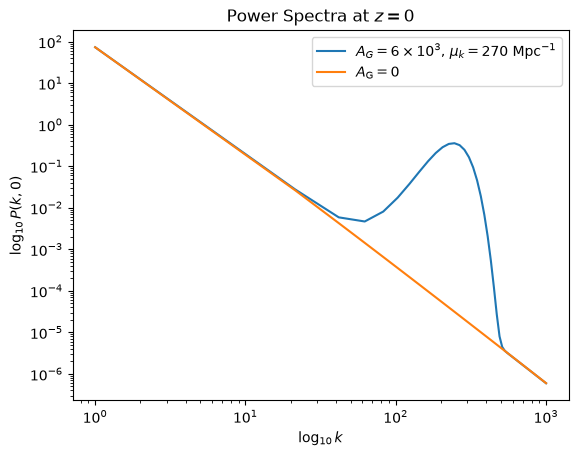

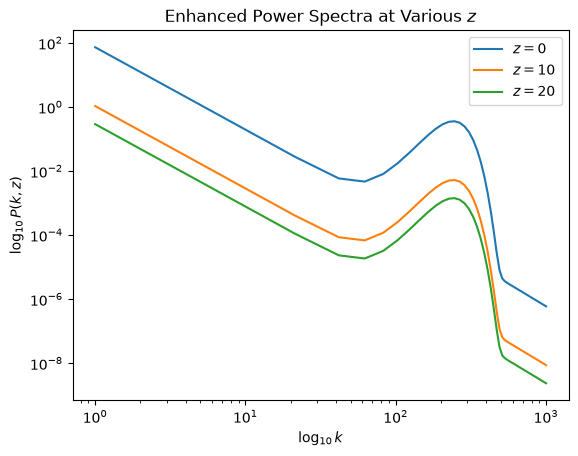

In [15]:
plt.loglog(k_range, P_test_vals[2][0], label = r'$A_G=6\times10^3$, $\mu_k=270$ Mpc$^{-1}$')

plt.loglog(k_range, P_old_test_vals[0], label = r'$A_\text{G}=0$')

plt.xlabel(r'$\log_{10}k$')
plt.ylabel(r'$\log_{10}P(k,0)$')

plt.legend()

plt.title(r'Power Spectra at $z=0$')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "EnhancedFull_PS_z0.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""
plt.show()

#const A_G, const k_\mu

plt.loglog(k_range, P_test_vals[2][0], label = r'$z=0$')
plt.loglog(k_range, P_test_vals[2][49], label = r'$z=10$')
plt.loglog(k_range, P_test_vals[2][99], label = r'$z=20$')

plt.xlabel(r'$\log_{10}k$')
plt.ylabel(r'$\log_{10}P(k,z)$')

plt.legend()

plt.title(r'Enhanced Power Spectra at Various $z$')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "EnhancedFull_PS_varyz.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""
plt.show()

In [16]:
#Sigma0 normalized

Enhanced_Sigma_Norm = [A_new * sigma_M_new(M, A_G_val, k_mean_val[2], k_std_val, z=0, cutoff = 10**10) for M in M_range_new]

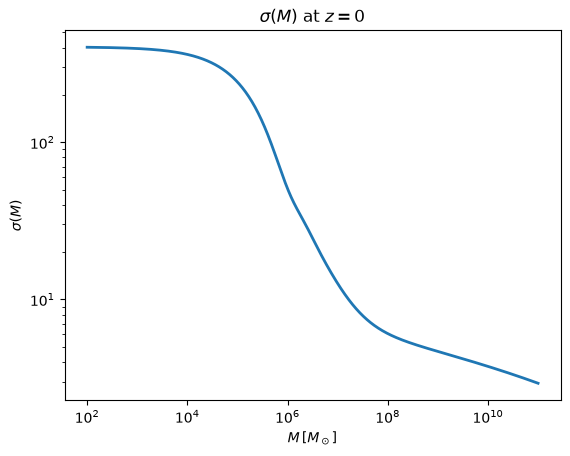

In [17]:
plt.loglog(M_range_new, Enhanced_Sigma_Norm, lw=2)

plt.xlabel(r"$M\,[M_\odot]$")
plt.ylabel(r"$\sigma(M)$")

plt.title(r'$\sigma(M)$ at $z=0$')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "EnhancedSigma0.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

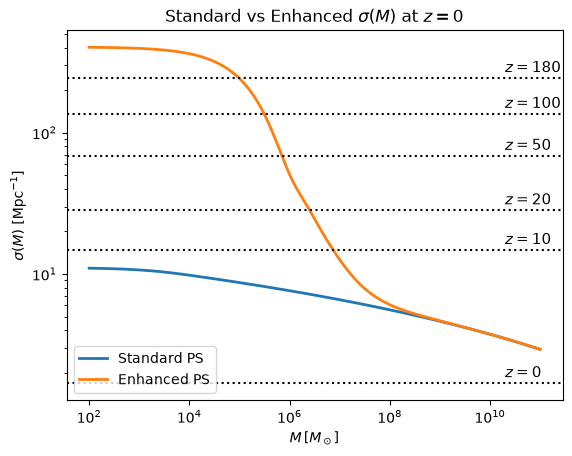

In [18]:
# Generating data for standard and enhanced PS for comparizon

# Standard PS
sigma_standard = np.array([
    TS.A * TS.sigma_M(M)
    for M in M_range_new
])

#Enhanced PS
plt.loglog(
    M_range_new,
    sigma_standard,
    lw=2,
    label='Standard PS'
)

plt.loglog(M_range_new, Enhanced_Sigma_Norm, lw=2, label = r'Enhanced PS')

#Plotting critical density contrasts at various redshifts

z_vals = [0, 10, 20, 50, 100, 180]

# x-position where the labels will appear
x_text = M_range_new[-1] / 5

for z in z_vals:

    delta_c_z = cosmo.delta_c / TS.D(z)

    plt.axhline(
        delta_c_z,
        ls=':',
        lw=1.5,
        color='k'
    )

    plt.text(
        x_text,
        delta_c_z * 1.03,      # slight offset above the line
        fr'$z={z}$',
        fontsize=11,
        ha='left',
        va='bottom'
    )

plt.xlabel(r'$M\,[M_\odot]$')
plt.ylabel(r'$\sigma(M)$ [Mpc$^{-1}$]')

plt.legend()

plt.title(r'Standard vs Enhanced $\sigma(M)$ at $z=0$')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "StandardvsEnhancedPSsigma0.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

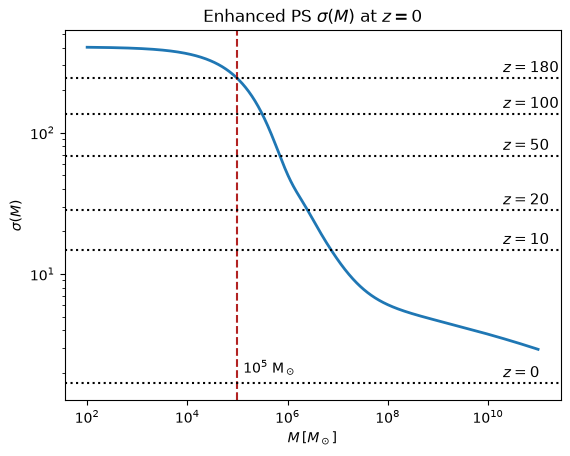

In [19]:
#Enhanced PS

plt.loglog(M_range_new, Enhanced_Sigma_Norm, lw=2)

plt.axvline(10 ** 5, ls = '--', color = r'firebrick')

plt.text(1.3 * 10 ** 5, 2, r'$10^5$ M$_\odot$')

#Plotting critical density contrasts at various redshifts

z_vals = [0, 10, 20, 50, 100, 180]

# x-position where the labels will appear
x_text = M_range_new[-1] / 5

for z in z_vals:

    delta_c_z = cosmo.delta_c / TS.D(z)

    plt.axhline(
        delta_c_z,
        ls=':',
        lw=1.5,
        color='k'
    )

    plt.text(
        x_text,
        delta_c_z * 1.03,      # slight offset above the line
        fr'$z={z}$',
        fontsize=11,
        ha='left',
        va='bottom'
    )

plt.xlabel(r'$M\,[M_\odot]$')
plt.ylabel(r'$\sigma(M)$')

plt.title(r'Enhanced PS $\sigma(M)$ at $z=0$')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "EnhancedPSsigma0.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [20]:
# Fitting the Standard Deviation for Differentiation
# Using cubic spline interpolation for fitting

# We define log arrays because the actual values span orders of magnitude

logM = np.log10(M_range_new) # Defining a log array of the mass range
logsigma = np.log10(Enhanced_Sigma_Norm) # Defining a log array of the standard deviation range

sigma_spline = CubicSpline(logM, logsigma) # Cubic spline interpolation in the log arrays

sigma_fit = 10**sigma_spline(logM) # Actual fit in linear scale

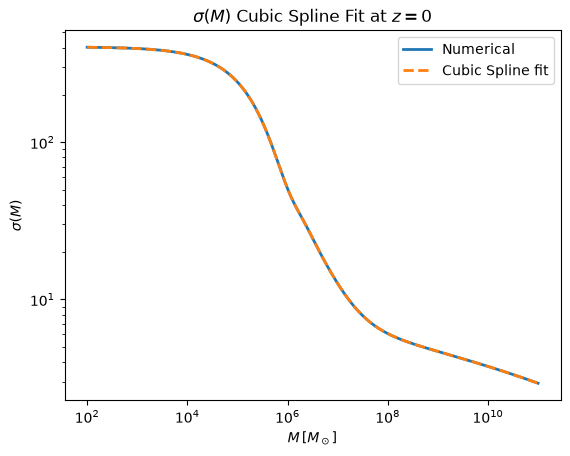

In [21]:
plt.loglog(M_range_new, Enhanced_Sigma_Norm, lw=2, label="Numerical")
plt.loglog(M_range_new, sigma_fit, '--', lw=2, label="Cubic Spline fit")

plt.xlabel(r"$M\,[M_\odot]$")
plt.ylabel(r"$\sigma(M)$")

plt.legend()

plt.title(r'$\sigma(M)$ Cubic Spline Fit at $z=0$')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "EnhancedPSsigma0CubSpFit.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [22]:
# Defining cubic spline fit as a function

def sigma_fit_new(M):
    return 10 ** sigma_spline(np.log10(M))

In [23]:
# Defining the derivative function of log sigma wrt log M

sigma_spline_deriv = sigma_spline.derivative() # Defining derivative function of the log sigma arr

# Defining dln(sigma)_dln(M) that goes in the PS formalism
def dlnsigma_dlnM_new(M):
    logM = np.log10(M)
    return sigma_spline_deriv(logM)

In [24]:
def PS_mass_function_new(M, z): # Returns dn/dlog_10M

    # Growth of fluctuations
    sigma = sigma_fit_new(M) * TS.D(z)

    # Peak height
    nu = cosmo.delta_c / sigma

    # Press-Schechter prefactor
    prefactor = (
        np.sqrt(2 / np.pi)
        * cosmo.rho_0
        / M
    )

    return (np.log(10) * 
        prefactor
        * nu
        * np.abs(dlnsigma_dlnM_new(M))
        * np.exp(-0.5 * nu**2)
    )

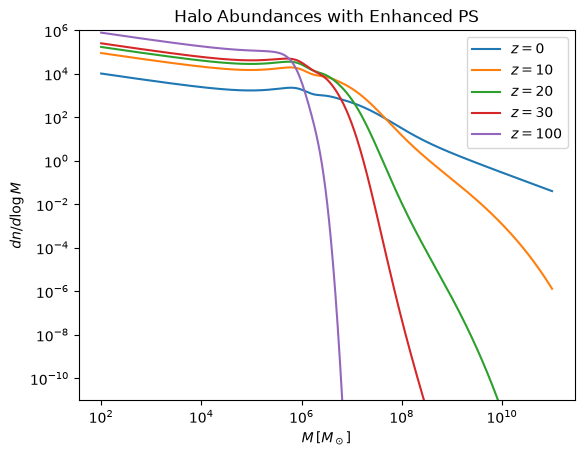

In [25]:
z_vals = [0, 10, 20, 30, 100]

for z in z_vals:

    dn = np.array([
        PS_mass_function_new(M, z)
        for M in M_range_new
    ])

    plt.loglog(
        M_range_new,
        dn,
        label=fr"$z={z}$"
    )

plt.xlabel(r"$M\,[M_\odot]$")
plt.ylabel(r"$dn/d\log M$")

plt.legend()

plt.ylim(10**(-11), 10**(6))

plt.title(r'Halo Abundances with Enhanced PS')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "EnhancedPSHaloAbund.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [26]:
dn_dlog10M_standard = np.array([TS.PS_MassFunc(M, 100) for M in M_range_new])
dn_dlog10M_enhanced = np.array([PS_mass_function_new(M, 100) for M in M_range_new])

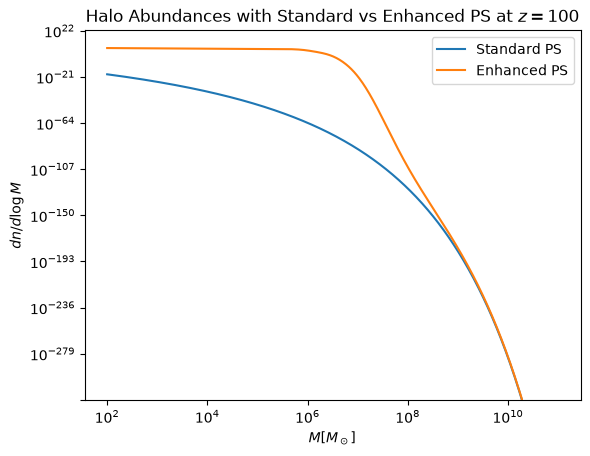

In [27]:
plt.loglog(M_range_new, dn_dlog10M_standard, label = r'Standard PS')
plt.loglog(M_range_new, dn_dlog10M_enhanced, label = r'Enhanced PS')

plt.xlabel(r'$M[M_\odot]$')
plt.ylabel(r'$dn/d\log M$')

plt.legend()

plt.title(r'Halo Abundances with Standard vs Enhanced PS at $z=100$')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "StandardEnhancedPSHaloAbundz100.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

#plt.ylim(0, 10**22)

plt.show()

## Star Formation Rate Density

In [49]:
# Defining the SFRD integral bounds on mass - M_min and M_max

min_T_vir = 300 #Molecular cooling above this temp
max_T_vir = 10 ** 4 #Atomic cooling threshold

neutral_mu = 1.23 # mean molecular weight

def M_factor(z): #The coefficient of M^1/3 in V_c formula
    Om_m_z = cosmo.Om_m * (1 + z) ** 3 / (cosmo.Om_m * (1 + z) ** 3 + cosmo.Om_lambda)
    d = Om_m_z - 1
    DELTA_c = 18 * np.pi ** 2 + 82 * d - 39 * d ** 2
    return 23.4 * (cosmo.Om_m / Om_m_z * DELTA_c / (18 * np.pi ** 2)) ** (1 / 6) * ((1 + z) / 10) ** (1 / 2) / (10 ** 8 * cosmo.h ** (-1)) ** (1 / 3)

def T_min_val(z):
    if z<= 160: #Adiabatic limit approximation
        # Barkana and Loeb Eqn. 49, minimum vir. temperature required for star formation in DM halos
        T_min = 3000 * ((1 + z) / 100) ** 2
    else: # Strong coupling limit
        T_min = 1.54 * 3 * (1 + z)
    # Minimum vir. temp for molecular cooling to take place even if the above condition is met
    if T_min <= 300:
        return 300 # if above temp is smaller than 300 K, we default to molecular cooling threshold
    else:
        return T_min

def min_V_c(z): # Circular halo velocity corresponding to minimum temperature
    return np.sqrt(T_min_val(z) * 2 * (cu.k_B / (1000) ** 2) / (neutral_mu * cu.m_p))

"""

z_t = 137 * (cosmo.Om_b * cosmo.h ** 2 / 0.022) ** (2 / 5) - 1

print(z_t)

"""

def M_min(z): # Minimum halo mass corresponding to minimum temperature freezing min mass beyond z=160
    if z <= 160:
        return (min_V_c(z) / M_factor(z)) ** 3
    else:
        return (min_V_c(160) / M_factor(160)) ** 3

"""

def M_min(z): # Based on strong coupling limit
    return (min_V_c(z) / M_factor(z)) ** 3

def M_min2(z): #Based on jeans mass
    if z <= 160:
        return (min_V_c(z) / M_factor(z)) ** 3
    else:
        # Barkana and Loeb Eqn. 40, minimum vir. temperature required for star formation in DM halos
        return 1.35 * 10 ** 5 * (cosmo.Om_m * cosmo.h ** 2 / 0.15) ** (-1 / 2)

"""
    
# Circular halo velocity corresponding to maximum temperature, atomic colling threshold
max_V_c = np.sqrt(max_T_vir * 2 * (cu.k_B / (1000) ** 2) / (neutral_mu * cu.m_p))

# Maximum halo mass corresponding to maximum temperature
def M_max(z):
    #return (max_V_c / M_factor(z)) ** (3)
    return 10 ** 11

In [50]:
# We find that collapse redshift is greater than z=160 where temp law does not hold, we will use z=160 for now.
z_early_grid = np.linspace(600, 20, 1500)

M_min_val_arr = np.zeros_like(z_early_grid) # initializing minimum mass array for each redshift
#M_min_val_arr2 = np.zeros_like(z_early_grid) # initializing minimum mass array for each redshift

"""

# Finding minimum mass at each z gridpoint, strong coupling scheme
for i in range(len(z_early_grid)):
    M_min_val_arr[i] = M_min(z_early_grid[i])

# Finding minimum mass at each z gridpoint, M_J scheme
for i in range(len(z_early_grid)):
    M_min_val_arr2[i] = M_min2(z_early_grid[i])


"""

# Finding minimum mass at each z gridpoint
for i in range(len(z_early_grid)):
    M_min_val_arr[i] = M_min(z_early_grid[i])

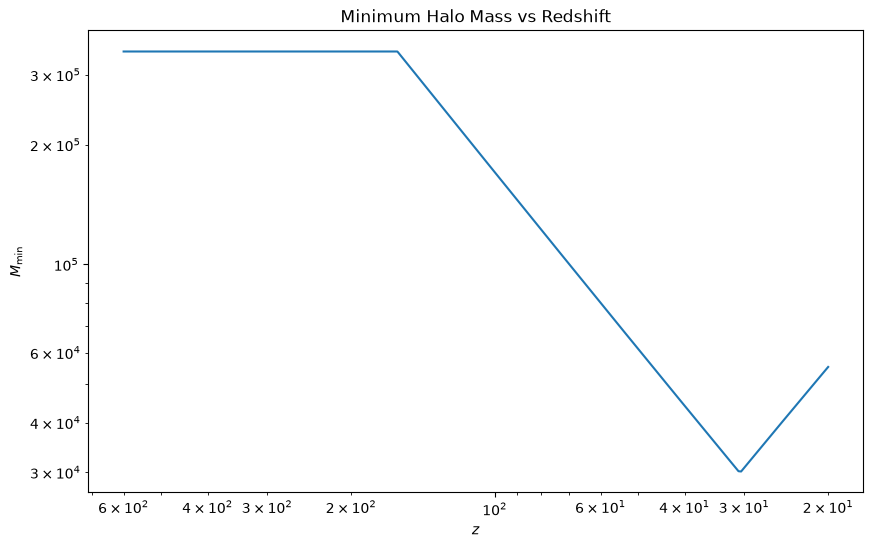

In [53]:
plt.figure(figsize=(10,6))
plt.loglog(z_early_grid, (M_min_val_arr))
#plt.loglog(z_early_grid, (M_min_val_arr2), label = r'Baryon Capture Condition')
plt.xlabel(r'$z$')
plt.ylabel(r'$M_\text{min}$')
plt.title(r'Minimum Halo Mass vs Redshift')

plt.gca().invert_xaxis()

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "MinimumHaloMass_BaryonCap.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

### Standard Power Spectrum

In [54]:
SFE = 10 ** (-3) #star formation efficiency
baryon_frac = cosmo.Om_b / cosmo.Om_m

def tau_ff(z): #in yr
    return 1 / np.sqrt(27 * np.pi ** 2 * cosmo.H(z) ** 2)

def SFRD_integrand_standard(M, SFE_val, z): #in SM/yr/Mpc^3
    return SFE_val * baryon_frac * M / tau_ff(z) * TS.PS_MassFunc(M, z)

In [55]:
def SFRD_Standard(z):
    # Logarithmically spaced halo mass grid
    Highz_MassRange = np.logspace(
        np.log10(M_min(z)),
        np.log10(M_max(z)),
        1000
    )

    logM = np.log10(Highz_MassRange)

    # Evaluate the integrand
    SFRD_integrand_vals = np.array([
        SFRD_integrand_standard(M, SFE, z)
        for M in Highz_MassRange
    ])

    # Integrate over log10(M)
    return simpson(SFRD_integrand_vals, x=logM)

In [56]:
standard_SFRD_early_arr = np.zeros_like(z_early_grid)

for i in range(len(z_early_grid)):
    standard_SFRD_early_arr[i] = SFRD_Standard(z_early_grid[i])

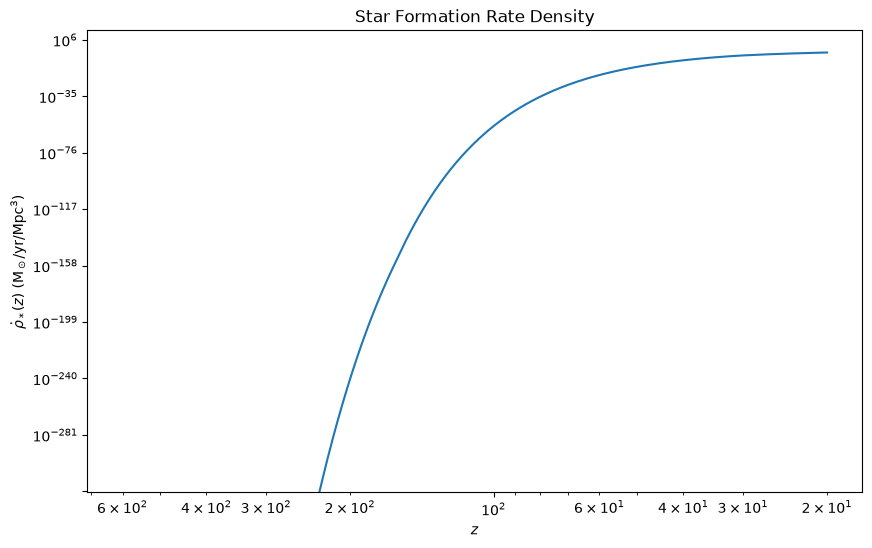

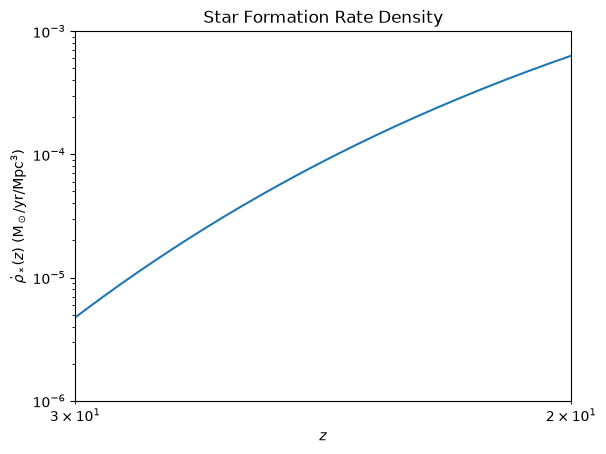

In [57]:
plt.figure(figsize = (10,6))
plt.loglog(z_early_grid, standard_SFRD_early_arr)
plt.gca().invert_xaxis()

plt.xlabel(r'$z$')
plt.ylabel(r'$\dot{\rho}_*(z)$ (M$_\odot$/yr/Mpc$^{3}$)')
plt.title(r'Star Formation Rate Density')

#plt.xlim(30, 20)
#plt.ylim(10 ** (-6), 10 ** (-3))

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "SFRDStandardPS_JeansExtension.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

plt.loglog(z_early_grid, standard_SFRD_early_arr)
plt.gca().invert_xaxis()

plt.xlabel(r'$z$')
plt.ylabel(r'$\dot{\rho}_*(z)$ (M$_\odot$/yr/Mpc$^{3}$)')
plt.title(r'Star Formation Rate Density')

plt.xlim(30, 20)
plt.ylim(10 ** (-6), 10 ** (-3))

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "SFRDStandardPSZoomIn_JeansExtension.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

### Enhanced Power Spectrum

In [58]:
def SFRD_integrand(M, SFE_val, z): #in SM/yr/Mpc^3
    return SFE_val * baryon_frac * M / tau_ff(z) * PS_mass_function_new(M, z)

In [59]:
def SFRD_Enhanced(z):
    # Logarithmically spaced halo mass grid
    Highz_MassRange = np.logspace(
        np.log10(M_min(z)),
        np.log10(M_max(z)),
        1000
    )

    logM = np.log10(Highz_MassRange)

    # Evaluate the integrand
    SFRD_integrand_vals = np.array([
        SFRD_integrand(M, SFE, z)
        for M in Highz_MassRange
    ])

    # Integrate over log10(M)
    return simpson(SFRD_integrand_vals, x=logM)

In [60]:
SFRD_early_arr = np.zeros_like(z_early_grid)

for i in range(len(z_early_grid)):
    SFRD_early_arr[i] = SFRD_Enhanced(z_early_grid[i])

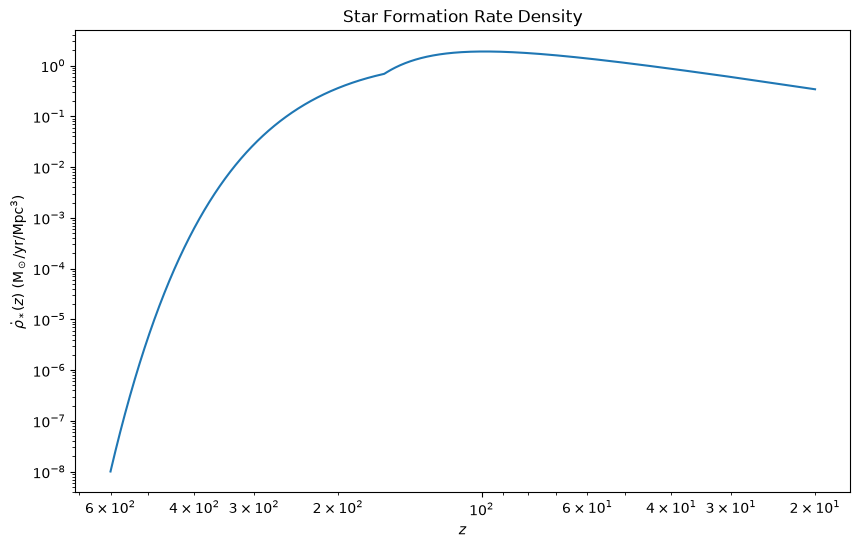

In [61]:
plt.figure(figsize = (10, 6))
plt.loglog(z_early_grid, SFRD_early_arr)
plt.gca().invert_xaxis()

plt.xlabel(r'$z$')
plt.ylabel(r'$\dot{\rho}_*(z)$ (M$_\odot$/yr/Mpc$^{3}$)')
plt.title(r'Star Formation Rate Density')

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "SFRDEnhancedPS_JeansExtension.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

## Cosmological Reionization at High Redshifts

In [71]:
# Finding rate of UV photons escaping

n_gamma = 83000 # number of ionizing photons per baryon
f_esc = 0.1 # escape fraction

def dN_dt_func_new(SFRD, z_arr, n_gamma_val, f_esc_val, f_HII): # Accounting for modified SFRD by reionized region
    return (1 - f_HII) * SFRD * (1 + z_arr) ** 3 * n_gamma_val * f_esc_val / (cu.m_p * cu.kgToSM)

dN_dt_standard = dN_dt = CR.dN_dt_func(standard_SFRD_early_arr, z_early_grid, n_gamma, f_esc)
dN_dt_enhanced = dN_dt = CR.dN_dt_func(SFRD_early_arr, z_early_grid, n_gamma, f_esc)

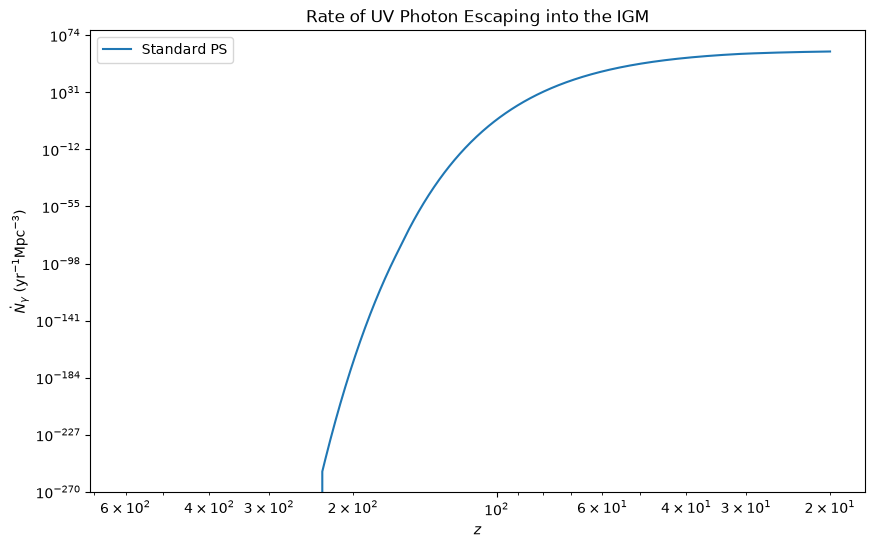

In [63]:
plt.figure(figsize = (10, 6))
plt.loglog(z_early_grid, dN_dt_standard, label = r'Standard PS')
plt.xlabel(r'$z$')
plt.ylabel(r'$\dot{N}_\gamma$ (yr$^{-1}$Mpc$^{-3}$)')

plt.title(r'Rate of UV Photon Escaping into the IGM')

plt.legend()#

plt.gca().invert_xaxis()

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "dNdtStandardPS_JeansExtension.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

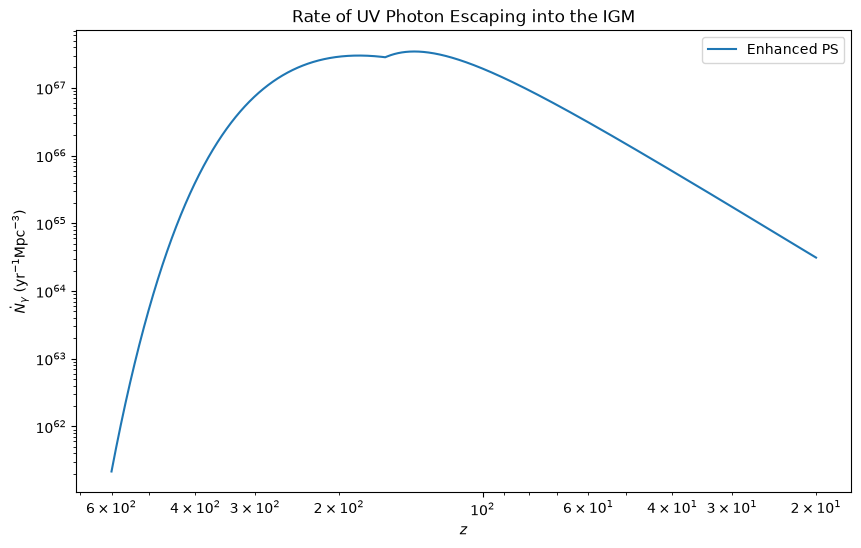

In [64]:
plt.figure(figsize = (10,6))
plt.loglog(z_early_grid, dN_dt_enhanced, label = r'Enhanced PS')
plt.xlabel(r'$z$')
plt.ylabel(r'$\dot{N}_\gamma$ (yr$^{-1}$Mpc$^{-3}$)')

plt.title(r'Rate of UV Photon Escaping into the IGM')

plt.legend()

plt.gca().invert_xaxis()

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "dNdtEnhancedPS_JeansExtension.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [65]:
def Solve_Reionization(z_grid, dN_dt_array, fHII_initial=2e-4):

    dNdt_interp = interp1d(
        z_grid,
        dN_dt_array,
        kind="cubic",
        bounds_error=False,
        fill_value="extrapolate"
    )

    fHII = np.zeros_like(z_grid)
    fHII[0] = fHII_initial

    for i in range(len(z_grid)-1):

        z = z_grid[i]

        source = (
            dNdt_interp(z)
            / CR.n_H(z)
            * CR.dt_dz(z)
        )

        recomb = (
            CR.alpha_B_unit
            * CR.n_H(z)
            * CR.Test_Clump(z)
            * fHII[i]
            * CR.dt_dz(z)
        )

        dfdz = source - recomb

        dz = z_grid[i+1] - z_grid[i]

        # Euler step
        f_next = fHII[i] + dfdz * dz

        # Physical bounds
        f_next = np.clip(f_next, 0.0, 1.0)

        fHII[i+1] = f_next

    return fHII

In [66]:
f_HII_standard = Solve_Reionization(z_early_grid, dN_dt_standard, fHII_initial=2e-4)
f_HII_enhanced = Solve_Reionization(z_early_grid, dN_dt_enhanced, fHII_initial=2e-4)

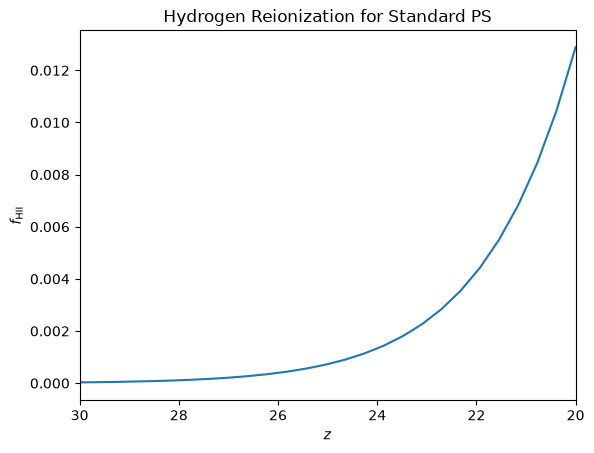

In [67]:
plt.plot(z_early_grid, f_HII_standard)
plt.xlabel(r'$z$')
plt.ylabel(r'$f_{\text{HII}}$')

plt.title(r'Hydrogen Reionization for Standard PS')
plt.xlim(20, 30)

plt.gca().invert_xaxis()

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "HReionStandardPS_JeansExtension.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

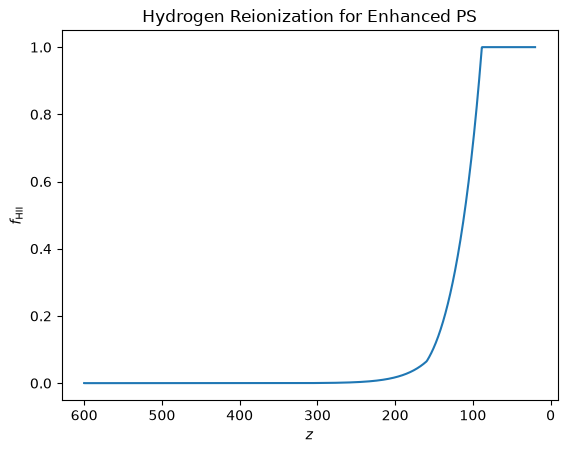

In [68]:
plt.plot(z_early_grid, f_HII_enhanced)
plt.xlabel(r'$z$')
plt.ylabel(r'$f_{\text{HII}}$')

plt.title(r'Hydrogen Reionization for Enhanced PS')

plt.gca().invert_xaxis()

"""

save_dir = "../Figures/Enhanced_Primordial_PS/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "HReionEnhancedPS_JeansExtension.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

### Optical Depth

In [69]:
#Inverting redshift and f_HII arrys:

z_early_grid_rev = z_early_grid[::-1]
f_HII_standard_rev = f_HII_standard[::-1]
f_HII_enhanced_rev = f_HII_enhanced[::-1]

StandardPS_OpticalDepth = CR.OpticalDepth(z_early_grid_rev, f_HII_standard_rev)
EnhancedPS_OpticalDepth = CR.OpticalDepth(z_early_grid_rev, f_HII_enhanced_rev)

In [70]:
print(StandardPS_OpticalDepth, EnhancedPS_OpticalDepth)

0.022966145878914882 98.1408597920216
